# Course NIGK21007U - Integrated Water Resources Modelling
## Tutorial 3

This notebook shows you how to visualize and analyze results from the Mike+ river model you built in Tutorial 3 in python and work with the results creatively.

First, load all necessary packages:

In [1]:
from mikeio1d import Res1D
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Define name and path to the results file you want to process.

In [2]:
# Replace 'path/to/your/results.res1d' with your actual file path
file_path = r'h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Tutorials\Tutorial_3\Susaa_m1d - Result Files\Susaa_1BaseDefault_Network_HD.res1d'

Open the file and read the item names:

In [3]:
# Use the Res1D class constructor
res = Res1D(file_path)
data = res.read()
print(data.keys())
all_keys = data.keys()

Index(['WaterLevel:'Susaa', 0', 'WaterLevel:'Susaa', 17988.921839836556',
       'WaterLevel:Susaa:0', 'WaterLevel:Susaa:100', 'WaterLevel:Susaa:200',
       'WaterLevel:Susaa:300', 'WaterLevel:Susaa:400', 'WaterLevel:Susaa:500',
       'WaterLevel:Susaa:600', 'WaterLevel:Susaa:700',
       ...
       'EnergyLevel:Susaa:17093.9', 'EnergyLevel:Susaa:17193.4',
       'EnergyLevel:Susaa:17292.8', 'EnergyLevel:Susaa:17392.2',
       'EnergyLevel:Susaa:17491.7', 'EnergyLevel:Susaa:17591.1',
       'EnergyLevel:Susaa:17690.6', 'EnergyLevel:Susaa:17790',
       'EnergyLevel:Susaa:17889.5', 'EnergyLevel:Susaa:17988.9'],
      dtype='str', length=1627)


Select your target reach, target variable and unit:

In [4]:
target_variable = "WaterLevel"
#target_variable = "Discharge"
target_reach = "Susaa"
#target_unit = 'm^3/s'
target_unit = 'mamsl'

Print all avaialble items in that reach and of that variable type:

In [8]:
selected_keys = [
    key for key in all_keys 
    if key.startswith(f"{target_variable}:") and target_reach in key
]

# Print the resulting list
print(f"--- {target_variable} Keys for {target_reach} ---")
for key in selected_keys:
    print(key)

timestamps = data.index

--- WaterLevel Keys for Susaa ---
WaterLevel:'Susaa', 0
WaterLevel:'Susaa', 17988.921839836556
WaterLevel:Susaa:0
WaterLevel:Susaa:100
WaterLevel:Susaa:200
WaterLevel:Susaa:300
WaterLevel:Susaa:400
WaterLevel:Susaa:500
WaterLevel:Susaa:600
WaterLevel:Susaa:700
WaterLevel:Susaa:800
WaterLevel:Susaa:900
WaterLevel:Susaa:1000
WaterLevel:Susaa:1100
WaterLevel:Susaa:1200
WaterLevel:Susaa:1300
WaterLevel:Susaa:1400
WaterLevel:Susaa:1500
WaterLevel:Susaa:1600
WaterLevel:Susaa:1700
WaterLevel:Susaa:1800
WaterLevel:Susaa:1900
WaterLevel:Susaa:2000
WaterLevel:Susaa:2100
WaterLevel:Susaa:2200
WaterLevel:Susaa:2300
WaterLevel:Susaa:2400
WaterLevel:Susaa:2500
WaterLevel:Susaa:2600
WaterLevel:Susaa:2700
WaterLevel:Susaa:2800
WaterLevel:Susaa:2900
WaterLevel:Susaa:3000
WaterLevel:Susaa:3100
WaterLevel:Susaa:3200
WaterLevel:Susaa:3300
WaterLevel:Susaa:3400
WaterLevel:Susaa:3500
WaterLevel:Susaa:3600
WaterLevel:Susaa:3700
WaterLevel:Susaa:3800
WaterLevel:Susaa:3900
WaterLevel:Susaa:4000
WaterLevel:Susa

Make time series plot for selected chainage:

Found column: WaterLevel:Susaa:10000


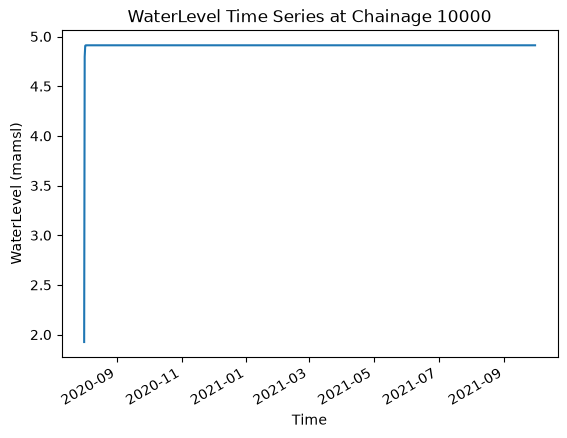

In [6]:
target_chainage = '10000'
target_column_name = None
for key in all_keys:
    # Check if the key contains both the variable and the chainage
    if target_variable in key and target_chainage in key:
        target_column_name = key
        break # Stop searching once found

if target_column_name:
    print(f"Found column: {target_column_name}")
else:
    print(f"Error: Could not find column for {target_variable} at chainage {target_chainage}")

if target_column_name:
    # Select the specific column from the DataFrame
    time_series_data = data[target_column_name]
    
    # Plotting is easy since the index (x-axis) is already the timestamps
    time_series_data.plot(
        title=f'{target_variable} Time Series at Chainage {target_chainage}',
        xlabel='Time',
        ylabel=f'{target_variable}' +' (' + target_unit + ')' # You'll need to fill in the correct unit!
    )

Make a profile plot for a selected time:

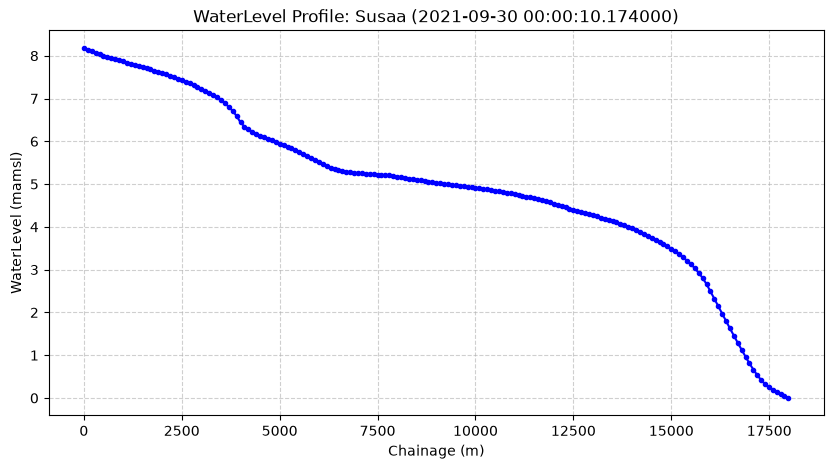

In [11]:
# 1. Select the nearest time slice directly using pandas indexing
target_dt = pd.to_datetime('2025-09-30 00:00:00')
idx = data.index.get_indexer([target_dt], method='nearest')[0]
profile_series = data.iloc[idx]
actual_time_str = data.index[idx]

# 2. Filter for key prefix (e.g. "WaterLevel:Susaa") and extract chainage (numeric end of index)
pattern = f"{target_variable}:{target_reach}"
matched = profile_series[profile_series.index.str.startswith(pattern)]

df = pd.DataFrame({
    'Chainage': matched.index.str.extract(r'([0-9.]+)$', expand=False).astype(float),
    target_variable: matched.values
}).dropna().sort_values('Chainage')

# 3. Plot if data exists
if df.empty:
    print("WARNING: No valid profile data found to plot.")
else:
    plt.figure(figsize=(10, 5))
    plt.plot(df['Chainage'], df[target_variable], 'b-o', markersize=3)
    plt.title(f'{target_variable} Profile: {target_reach} ({actual_time_str})')
    plt.xlabel('Chainage (m)')
    plt.ylabel(f'{target_variable} ({target_unit})')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()